# Setup

In [1]:
import numpy as np
from pathlib import Path
import numpy as np
import random
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Fix randomness for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', None)

In [2]:
# Paths and volume_to_fill
root = Path("data") if Path("data").exists() else Path.cwd()

if str(root / "src") not in sys.path:
    sys.path.append(str(root / "src"))

cryptos = [f for f in os.listdir(root) if "USDT" in f]

crypto = cryptos[6]

symbol_dir = root / crypto
X_path = symbol_dir / "X_train.parquet"
X_test_path = symbol_dir / "X_test.parquet"
Y_path = symbol_dir / "y_train.parquet"
vol_path = symbol_dir / "vol_to_fill.txt"

# X_train = pd.read_parquet(X_path).sort_values(["anonymized_id", "time_in_hour"])
# X_test = pd.read_parquet(X_test_path).sort_values(["anonymized_id", "time_in_hour"])
y_train = pd.read_parquet(Y_path).sort_values(["anonymized_id", "time_in_hour"])

volume_to_fill = None
if vol_path.exists():
    import re
    with open(vol_path) as f:
        m = re.search(r"([\d.]+)", f.read())
    if m:
        volume_to_fill = float(m.group(1))
print("crypto:", crypto)
print("volume_to_fill:", volume_to_fill)


crypto: LTCUSDT
volume_to_fill: 51.0


In [3]:
ASK_PRICE_COLS = ['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4', 'ask_price_5']
ASK_VOL_COLS = ['ask_vol_1', 'ask_vol_2', 'ask_vol_3', 'ask_vol_4', 'ask_vol_5']
BID_PRICE_COLS = ['bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4', 'bid_price_5']
BID_VOL_COLS = ['bid_vol_1', 'bid_vol_2', 'bid_vol_3', 'bid_vol_4', 'bid_vol_5']
OHLC_COLS = ['open', 'high', 'low', 'close']

price_cols = ASK_PRICE_COLS + BID_PRICE_COLS + OHLC_COLS
vol_cols = ASK_VOL_COLS + BID_VOL_COLS + ["volume"]

# Imputations

In [4]:
ids = y_train["anonymized_id"].unique()
times = np.sort(y_train["time_in_hour"].unique())

full_index = pd.MultiIndex.from_product(
    [ids, times],
    names=["anonymized_id", "time_in_hour"]
)

y_train = (
    y_train
    .set_index(["anonymized_id", "time_in_hour"])
    .reindex(full_index)
    .reset_index()
)

# Volume fill with 0
y_train[vol_cols] = y_train[vol_cols].fillna(0)

y_train[price_cols] = (
    y_train
    .groupby("anonymized_id")[price_cols]
    .apply(lambda df: df.ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Generate Positions

In [5]:
from utils import PositionPredictor

pp = PositionPredictor(y_train, ASK_PRICE_COLS, ASK_VOL_COLS, BID_PRICE_COLS, BID_VOL_COLS, volume_to_fill)
pp_ask = PositionPredictor(y_train, ASK_PRICE_COLS, ASK_VOL_COLS, BID_PRICE_COLS, BID_VOL_COLS, volume_to_fill, side = "ask")


## Positions BPS

In [6]:
# baseline last 60 seconds

pp.compute_execution_metrics("baseline", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("baseline", K_seconds=60)["mean_bps"]

(np.float64(7.984649135430245), np.float64(5.621649792596623))

In [7]:
# midprice weighting

pp.compute_execution_metrics("mid", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("mid", K_seconds=60)["mean_bps"]

(np.float64(6.33935823910266), np.float64(4.815589210489752))

In [8]:
# midprice weighting last 14 seconds

pp.compute_execution_metrics("mid", K_seconds=14)["mean_bps"], pp_ask.compute_execution_metrics("mid", K_seconds=14)["mean_bps"]

(np.float64(6.488808174321846), np.float64(4.811488830927494))

In [9]:
# VWAP
pp.compute_execution_metrics("vwap", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("vwap", K_seconds=60)["mean_bps"]

(np.float64(5.952238740107106), np.float64(5.22198719929715))

In [10]:
# linear time-weighted VWAP
pp.compute_execution_metrics("vwap", weighting="linear", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("vwap", weighting="linear", K_seconds=60)["mean_bps"]

(np.float64(5.802580456641507), np.float64(5.094480764559912))

In [11]:
# quadratic time-weighted VWAP
pp.compute_execution_metrics("vwap", weighting="quadratic", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("vwap", weighting="quadratic", K_seconds=60)["mean_bps"]

(np.float64(5.960200634874574), np.float64(5.199939145897668))

In [12]:
# microprice
pp.compute_execution_metrics("micro", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("micro", K_seconds=60)["mean_bps"]

(np.float64(7.317487693745888), np.float64(5.181658537616389))

In [13]:
# close
pp.compute_execution_metrics("close", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("close", K_seconds=60)["mean_bps"]

(np.float64(7.607562820946952), np.float64(5.182580387543382))

In [14]:
# OBI (order book imbalance)
pp.compute_execution_metrics("obi", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("obi", K_seconds=60)["mean_bps"]

(np.float64(8.736854008683096), np.float64(6.019971802624988))

In [15]:
# OFI (with sign)
pp.compute_execution_metrics("ofi", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("ofi", K_seconds=60)["mean_bps"]

(np.float64(9.723035378504402), np.float64(7.224469753101976))

In [16]:
# spread
pp.compute_execution_metrics("spread", K_seconds=60)["mean_bps"], pp_ask.compute_execution_metrics("spread", K_seconds=60)["mean_bps"]

(np.float64(4.4435152229699995), np.float64(3.749980069550853))

In [20]:
# OFI + spread + close
ofispreadclosestrat = [
    {"strategy": "ofi", "weighting": "uniform", "K_seconds": 10, "fraction": 1/4},
    {"strategy": "spread", "weighting": "uniform", "K_seconds": 60, "fraction": 1/4},
    {"strategy": "close", "weighting": "uniform", "K_seconds": 60, "fraction": 2/4}
]
pp.compute_execution_metrics(ofispreadclosestrat)["mean_bps"], pp_ask.compute_execution_metrics(ofispreadclosestrat)["mean_bps"]

(np.float64(6.904533365101631), np.float64(4.861665580848241))

# Strategy Plotting

In [18]:
results = []

for K in range(60, 1, -5):
    
    baseline = pp.compute_execution_metrics("baseline", weighting="uniform", K_seconds=K)
    baseline_linear = pp.compute_execution_metrics("baseline", weighting="linear", K_seconds=K)
    baseline_quadratic = pp.compute_execution_metrics("baseline", weighting="quadratic", K_seconds=K)
    mid = pp.compute_execution_metrics("mid", K_seconds=K)
    vwap = pp.compute_execution_metrics("vwap", K_seconds=K)
    micro = pp.compute_execution_metrics("micro", K_seconds=K)
    ofi = pp.compute_execution_metrics("ofi", K_seconds=K)
    obi = pp.compute_execution_metrics("obi", K_seconds=K)
    spread = pp.compute_execution_metrics("spread", K_seconds=K)
    close = pp.compute_execution_metrics("close", K_seconds=K)

    baseline_ask = pp_ask.compute_execution_metrics("baseline", weighting="uniform", K_seconds=K)
    baseline_ask_linear = pp_ask.compute_execution_metrics("baseline", weighting="linear", K_seconds=K)
    baseline_ask_quadratic = pp_ask.compute_execution_metrics("baseline", weighting="quadratic", K_seconds=K)
    mid_ask = pp_ask.compute_execution_metrics("mid", K_seconds=K)
    vwap_ask = pp_ask.compute_execution_metrics("vwap", K_seconds=K)
    micro_ask = pp_ask.compute_execution_metrics("micro", K_seconds=K)
    ofi_ask = pp_ask.compute_execution_metrics("ofi", K_seconds=K)
    obi_ask = pp_ask.compute_execution_metrics("obi", K_seconds=K)
    spread_ask = pp_ask.compute_execution_metrics("spread", K_seconds=K)
    close_ask = pp_ask.compute_execution_metrics("close", K_seconds=K)

    results.append({"strategy": "baseline", "K": K, "weighting": "uniform", "mean_bps": baseline["mean_bps"], "mean_bps_ask": baseline_ask["mean_bps"]})
    results.append({"strategy": "baseline", "K": K, "weighting": "linear", "mean_bps": baseline_linear["mean_bps"], "mean_bps_ask": baseline_ask_linear["mean_bps"]})
    results.append({"strategy": "baseline", "K": K, "weighting": "quadratic", "mean_bps": baseline_quadratic["mean_bps"], "mean_bps_ask": baseline_ask_quadratic["mean_bps"]})
    results.append({"strategy": "mid", "K": K, "weighting": "uniform", "mean_bps": mid["mean_bps"], "mean_bps_ask": mid_ask["mean_bps"]})
    results.append({"strategy": "vwap", "K": K, "weighting": "uniform", "mean_bps": vwap["mean_bps"], "mean_bps_ask": vwap_ask["mean_bps"]})
    results.append({"strategy": "micro", "K": K, "weighting": "uniform", "mean_bps": micro["mean_bps"], "mean_bps_ask": micro_ask["mean_bps"]})
    results.append({"strategy": "ofi", "K": K, "weighting": "uniform", "mean_bps": ofi["mean_bps"], "mean_bps_ask": ofi_ask["mean_bps"]})
    results.append({"strategy": "obi", "K": K, "weighting": "uniform", "mean_bps": obi["mean_bps"], "mean_bps_ask": obi_ask["mean_bps"]})
    results.append({"strategy": "spread", "K": K, "weighting": "uniform", "mean_bps": spread["mean_bps"], "mean_bps_ask": spread_ask["mean_bps"]})
    results.append({"strategy": "close", "K": K, "weighting": "uniform", "mean_bps": close["mean_bps"], "mean_bps_ask": close_ask["mean_bps"]})

df_results = pd.DataFrame(results)

# rank all models
df_ranked = df_results.sort_values("mean_bps").reset_index(drop=True)

df_ranked.to_csv(f"csvs/position_pred_results_{crypto}.csv", index=False)

In [19]:
summary = df_results.groupby(["strategy", "weighting"])[["mean_bps","mean_bps_ask"]].mean().sort_values("mean_bps")
summary

mean_bps  mean_bps_ask
strategy weighting                         
spread   uniform     4.345377      3.484007
mid      uniform     6.449543      4.856364
vwap     uniform     6.647589      5.590160
micro    uniform     7.205284      5.110993
baseline uniform     7.817906      5.444222
         linear      7.834008      5.461207
         quadratic   8.428688      5.986116
close    uniform     8.449923      5.283061
obi      uniform     8.891856      6.142678
ofi      uniform    10.647024      6.961770

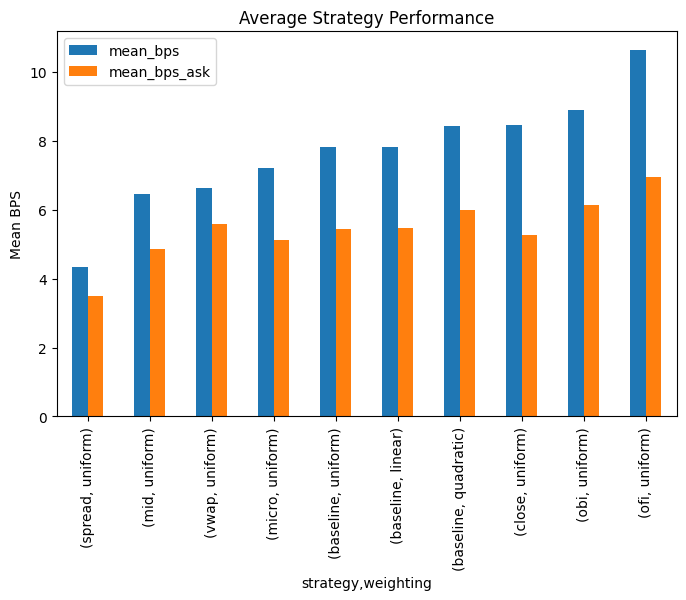

In [20]:
summary.plot(kind="bar", figsize=(8,5))
plt.title("Average Strategy Performance")
plt.ylabel("Mean BPS")
plt.show()

In [21]:
# explore what the current best approaches are

In [22]:
# ensemble of the above (weigh proportions equally)

In [23]:
# take trend of price movement into account

In [24]:
# maybe a modeling approach? try to take the gradient of objective